<center><font color="brown" size="6"><b>Week 27: Graded Mini Project</b></font></center>

**Project title**: Benchmarking RNNs and Transformers for Text Classification

**Objective**: Benchmark and compare Simple RNN and BiLSTM models trained from
scratch with a pretrained Hugging Face Transformer, applied to either IMDb sentiment
analysis (binary) or AG News classification (4-class). Measure and interpret accuracy, F1-
score, speed, and generalization capability.

## <font color="brown">Task 1: Dataset & Splits</font>

### <font color="orange">A. Load the Dataset</font>

In [1]:
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np

splits = ["train[:80%]", "train[80%:]", "test"]
DATASET_NAME = "imdb_reviews"

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    DATASET_NAME,
    split=splits,
    as_supervised=True,
    with_info=True
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LNOV0H_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LNOV0H_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LNOV0H_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
   

In [2]:
def ds_to_dataframe(ds, sample_size=5000):
    texts, labels = [], []
    for text, label in tfds.as_numpy(ds.take(sample_size)):
        texts.append(text.decode("utf-8"))
        labels.append(label)
    return pd.DataFrame({"text": texts, "label": labels})

df_sample = ds_to_dataframe(ds_train)
df_sample.head()

df_sample.info()
df_sample.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


,label
count,5000.000000
mean,0.505200
std,0.500023
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [4]:
df_sample.info()
df_sample.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


,label
count,5000.000000
mean,0.505200
std,0.500023
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## <font color="brown">Task 2: Model Implementations (from scratch)</font>

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN = 200

def extract_data(ds):
    texts, labels = [], []
    for text, label in tfds.as_numpy(ds):
        texts.append(text.decode("utf-8"))
        labels.append(label)
    return texts, np.array(labels).reshape(-1,1)

train_texts, train_labels = extract_data(ds_train)
val_texts, val_labels = extract_data(ds_val)
test_texts, test_labels = extract_data(ds_test)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=MAX_LEN)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=MAX_LEN)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=MAX_LEN)

### <font color="orange">A. Simple RNN: Embedding → SimpleRNN → Dropout → Dense(logits).</font>

In [6]:
from tensorflow.keras import layers, models

def build_simple_rnn():
    return models.Sequential([
        layers.Embedding(VOCAB_SIZE, 128),
        layers.SimpleRNN(64),
        layers.Dropout(0.5),
        layers.Dense(1)
    ])

simple_rnn = build_simple_rnn()
simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### <font color="orange">B. BiLSTM: Embedding → Bidirectional(LSTM) → Dropout → Dense(logits).</font>

In [7]:
def build_bilstm():
    return models.Sequential([
        layers.Embedding(VOCAB_SIZE, 128),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.5),
        layers.Dense(1)
    ])

bilstm = build_bilstm()
bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## <font color="brown">Task 3a: Training (scratch models)</font>

In [8]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2)
]

# Simple RNN
simple_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)

history_rnn = simple_rnn.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

# BiLSTM
bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)

history_bilstm = bilstm.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.5572 - loss: 0.6594 - val_accuracy: 0.7978 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8414 - loss: 0.3721 - val_accuracy: 0.7814 - val_loss: 0.4591 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9314 - loss: 0.1811 - val_accuracy: 0.8014 - val_loss: 0.4882 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9860 - loss: 0.0579 - val_accuracy: 0.8216 - val_loss: 0.4972 - learning_rate: 1.0000e-04
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.6820 - loss: 0.5434 - val_accuracy: 0.8556 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9176 - loss: 0.2203 - val_accuracy: 0.8616 - val_loss: 0.3161 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9437 - l

## <font color="brown">Task 3b: Evaluation (scratch models)</font>

In [9]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate_model(model):
    logits = model.predict(X_test)
    preds = (tf.sigmoid(logits).numpy() > 0.5).astype(int)
    acc = accuracy_score(test_labels, preds)
    f1  = f1_score(test_labels, preds)
    cm  = confusion_matrix(test_labels, preds)
    return acc, f1, cm

rnn_acc, rnn_f1, rnn_cm = evaluate_model(simple_rnn)
bilstm_acc, bilstm_f1, bilstm_cm = evaluate_model(bilstm)

print("Simple RNN:", rnn_acc, rnn_f1)
print("BiLSTM:", bilstm_acc, bilstm_f1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
Simple RNN: 0.802 0.7862878853294188
BiLSTM: 0.85748 0.8591977869986168


### <font color="orange">Plot training/validation loss & accuracy curves.</font>

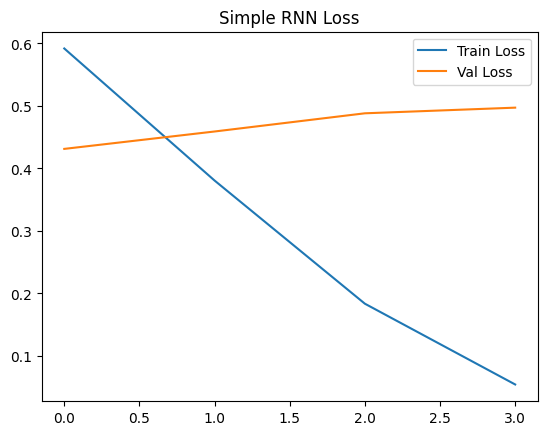

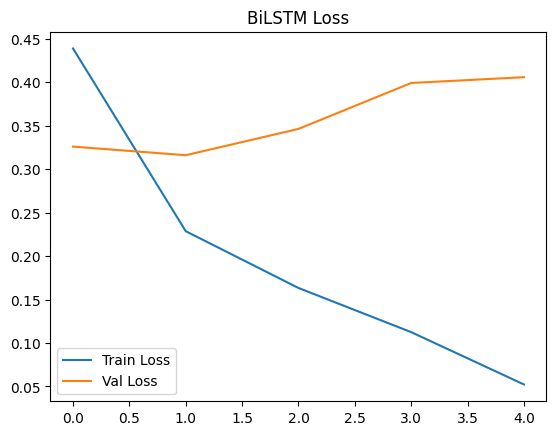

In [10]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title(title)
    plt.show()

plot_history(history_rnn, "Simple RNN Loss")
plot_history(history_bilstm, "BiLSTM Loss")

## <font color="brown">Task 4: Hugging Face Transformer (inference-only)</font>

In [11]:
!pip install -q transformers torch

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, time

model_name = "textattack/bert-base-uncased-imdb"

tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSequenceClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_hf.to(device)
model_hf.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [13]:
def transformer_inference(texts, batch_size=128):
    all_preds = []
    start = time.time()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encodings = tokenizer_hf(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt"
        )

        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model_hf(**encodings)

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

    end = time.time()
    return np.array(all_preds), end - start

In [14]:
preds_hf, inference_time = transformer_inference(test_texts)

hf_acc = accuracy_score(test_labels.flatten(), preds_hf)
hf_f1  = f1_score(test_labels.flatten(), preds_hf)

print("Transformer:", hf_acc, hf_f1)
print("Inference Time:", inference_time)

Transformer: 0.89088 0.8913407153668446
Inference Time: 243.63578462600708


## <font color="brown">Task 5: Comparison & Analysis</font>

In [15]:
results = pd.DataFrame({
    "Model": ["Simple RNN", "BiLSTM", "BERT"],
    "Test Accuracy": [rnn_acc, bilstm_acc, hf_acc],
    "F1 Score": [rnn_f1, bilstm_f1, hf_f1]
})

results

,Model,Test Accuracy,F1 Score
0,Simple RNN,0.80200,0.786288
1,BiLSTM,0.85748,0.859198
2,BERT,0.89088,0.891341


### <font color="orange">Conclusion</font>

- Transformer (BERT) performs best because it is pretrained on large text corpora and already understands general language patterns.
- RNN and BiLSTM were trained from scratch, so they learned only from the IMDb dataset, which limits their performance.
- BiLSTM performs better than Simple RNN because it captures context from both directions.
- The Transformer uses self-attention, which models long-range relationships better than sequential RNN processing.
- In terms of data efficiency, the Transformer benefits from prior knowledge (transfer learning), while RNN models need more task-specific data.
- However, the Transformer has higher computational cost and latency, especially without GPU.
- RNN and BiLSTM are faster and lighter, making them more suitable for low-resource or real-time deployment.

Overall, the results show a trade-off between higher accuracy (Transformer) and faster inference (RNN/BiLSTM).

## <font color="brown">Task 6: Reproducibility</font>

In [16]:
import random, sys, transformers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", device)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Device: cuda
